# Flow + Membrane Hybrid Segmentation — walkthrough

Interactive companion to `flow_membrane_seg.py`. Same frozen pipeline, step by step, with plots.

**Idea:** each signal does only what it is reliable at —
- **flow divergence** -> cell *centers* (markers), robust even with dim membrane
- **membrane wall** -> boundary *where a wall exists*
- **flow separatrix** -> boundary *where membrane is absent* (no arbitrary/adjacency guesses)
- **membrane veto** -> drop splits with no wall behind them

Input is a Cellpose `*_seg.npy` (has `img`, `flows`, and usually `masks`).
Keep this notebook next to `flow_membrane_seg.py`.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries
from skimage.morphology import dilation, disk

import flow_membrane_seg as fm   # the packaged module (same folder)

SEG_PATH = "/Users/amir/data/positivity_map/version_2/segmetation/test/A_3d/A_3d_C01_R01/A_3d_C01_R01_default_seg.npy"   # <-- your *_seg.npy
CROP = (560, 560, 1000)                      # (y, x, size); None = full tile

## 1. Load and run the full pipeline

In [35]:
seg = fm.load_seg(SEG_PATH)
params = fm.Params()          # defaults; edit the three knobs in section 5
labels, ctx = fm.run_pipeline(seg, params)

base = int(np.asarray(seg["masks"]).max()) if seg.get("masks") is not None else None
print(f"flow sinks : {ctx['n_markers']}")
print(f"Cellpose   : {base}")
print(f"pipeline   : {ctx['n_cells']}")
print(f"nucleus is plane {ctx['nuc_plane']}  (auto-detected)")

flow sinks : 317
Cellpose   : 199
pipeline   : 275
nucleus is plane 1  (auto-detected)


## 2. The channels (auto-detected)
Nucleus = the channel bright at the flow sinks; the other is membrane.

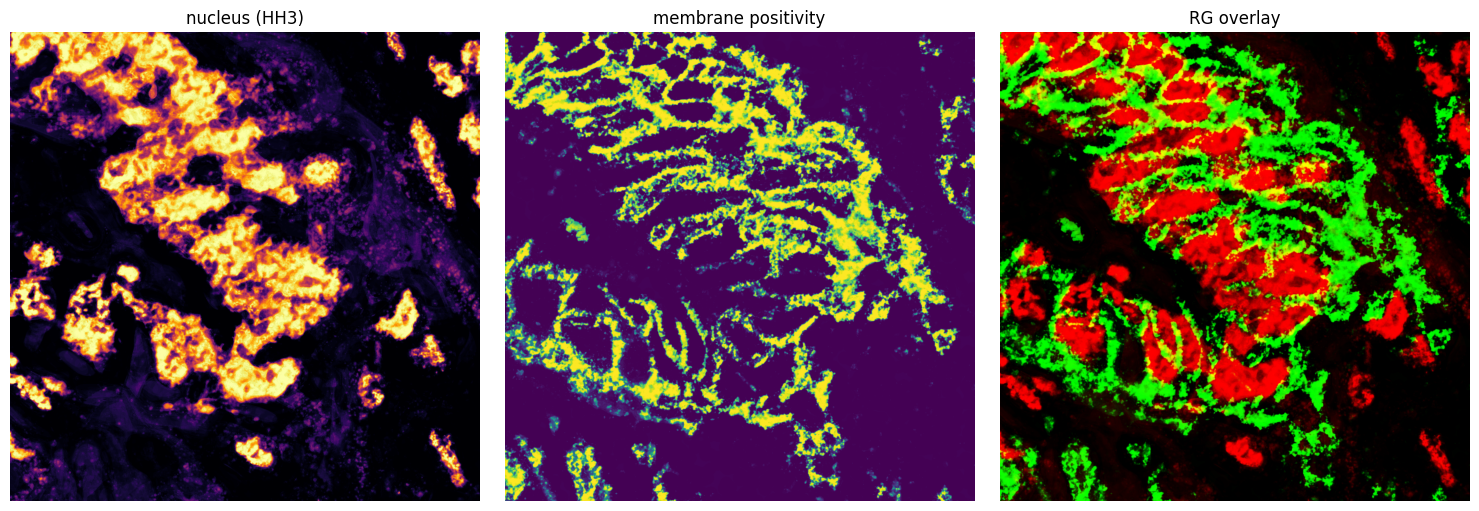

In [36]:
def crop(a, C=CROP):
    if C is None: return a
    y,x,s = C; return a[y:y+s, x:x+s]

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(crop(ctx['nucleus']), cmap='inferno'); ax[0].set_title('nucleus (HH3)')
ax[1].imshow(crop(ctx['membrane']), cmap='viridis'); ax[1].set_title('membrane positivity')
rg = np.zeros(crop(ctx['nucleus']).shape+(3,))
rg[...,0]=np.clip(crop(ctx['nucleus']),0,1); rg[...,1]=np.clip(crop(ctx['membrane']),0,1)
ax[2].imshow(rg); ax[2].set_title('RG overlay')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 3. Flow divergence -> sinks
Divergence is strongly **negative at cell centers** (sinks = markers) and **positive along seams** (watershed ridges). Watershed *this*, not the flow magnitude.

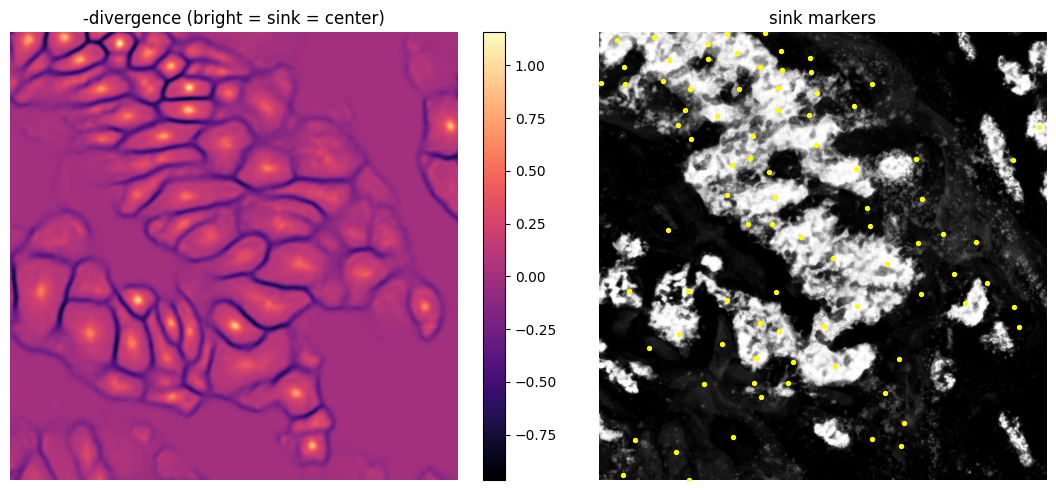

In [37]:
div = ctx['div']
fig, ax = plt.subplots(1, 2, figsize=(11,5))
im0 = ax[0].imshow(crop(-div), cmap='magma'); ax[0].set_title('-divergence (bright = sink = center)')
plt.colorbar(im0, ax=ax[0], fraction=0.046)
ax[1].imshow(crop(ctx['nucleus']), cmap='gray')
ys,xs = np.where(crop(ctx['markers'])>0); ax[1].scatter(xs, ys, s=8, c='yellow')
ax[1].set_title('sink markers')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 4. Elevation and result
Elevation = membrane wall (+skeleton) + `flow_weight` x divergence. Membrane wins where it exists; the flow separatrix places the seam where membrane is absent.

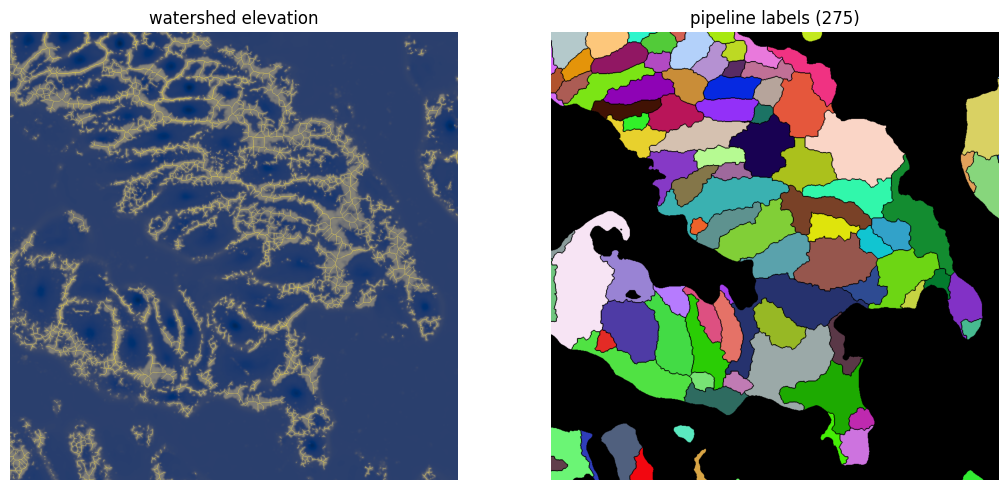

In [38]:
elev = fm.build_elevation(ctx['membrane'], div, params)
fig, ax = plt.subplots(1, 2, figsize=(11,5))
ax[0].imshow(crop(elev), cmap='cividis'); ax[0].set_title('watershed elevation'); ax[0].axis('off')
rng = np.random.default_rng(0)
lut = rng.random((int(labels.max())+1,3)); lut[0]=0
lab_rgb = lut[crop(labels)]
lab_rgb[find_boundaries(crop(labels),mode='inner')] = 0
ax[1].imshow(lab_rgb); ax[1].set_title(f'pipeline labels ({int(labels.max())})'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## 5. Compare to Cellpose + tune the three knobs
Yellow (solid) = Cellpose, cyan (dashed) = pipeline. Edit `sink_h` / `flow_weight` / `veto_wall` and re-run.

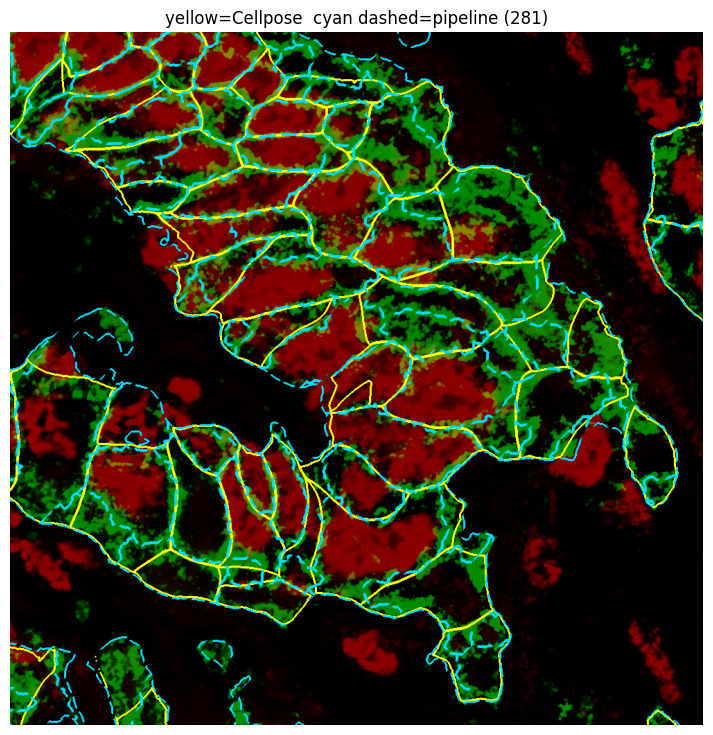

In [39]:
params = fm.Params(sink_h=0.12, flow_weight=2, veto_wall=0.45)   # <-- the three knobs
labels, ctx = fm.run_pipeline(seg, params)

y,x,s = CROP if CROP else (0,0,min(ctx['nucleus'].shape))
sub = np.s_[y:y+s, x:x+s]
rgb = np.zeros((s,s,3),np.float32)
rgb[...,0]=np.clip(ctx['nucleus'][sub],0,1); rgb[...,1]=np.clip(ctx['membrane'][sub],0,1); rgb*=0.55
out=(np.clip(rgb,0,1)*255).astype(np.uint8)
fb=dilation(find_boundaries(labels[sub],mode='inner'),disk(1))
Y,X=np.mgrid[0:s,0:s]; fb=fb&(((X+Y)%30)<22)
if seg.get('masks') is not None:
    cb=dilation(find_boundaries(np.asarray(seg['masks'])[sub],mode='inner'),disk(1)); out[cb]=[255,255,0]
out[fb]=[0,220,255]
plt.figure(figsize=(9,9)); plt.imshow(out)
plt.title(f"yellow=Cellpose  cyan dashed=pipeline ({int(labels.max())})"); plt.axis('off'); plt.show()

## 6. Preview hole removal — VISUALIZATION ONLY

The real hole removal happens inside `flow_membrane_seg.py` (`remove_holey`, controlled
by `hole_ratio` in `Params`, currently 0.99). This cell does **not** process anything that
gets saved — it only lets you *see* which masks a given `hole_ratio` would delete, so you
can pick the value to set in the `.py` file.

Keep `PREVIEW_RATIO` here equal to `hole_ratio` in the script so the preview matches the batch.
`ratio = real area / hole-filled area`;  1.0 = solid, below cutoff = has a hole.

total cells      : 281
cells with holes : 7
after removal    : 274


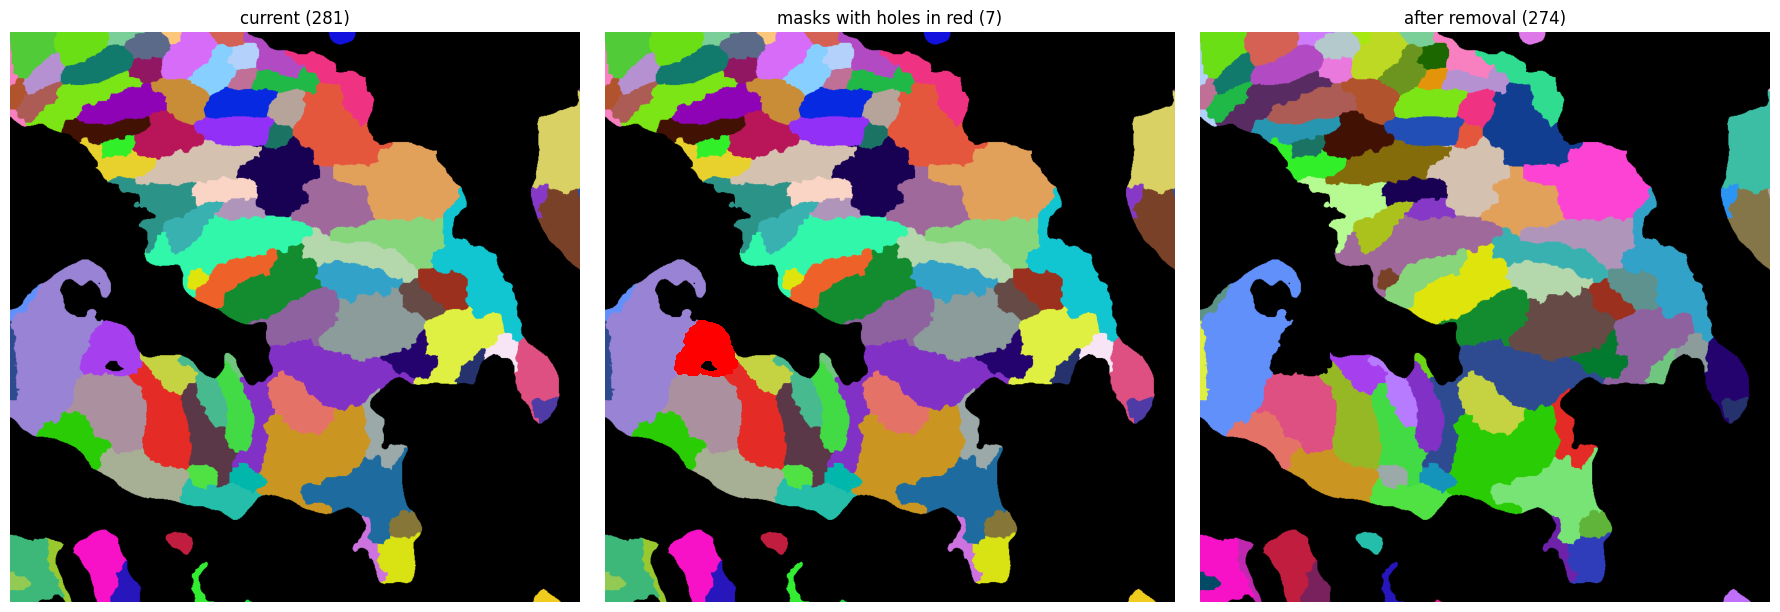

In [40]:
# VISUALIZATION ONLY — nothing here is saved. The script already removes holes.
# Use this to choose hole_ratio, then set that same value in Params in flow_membrane_seg.py.
from scipy.ndimage import binary_fill_holes
from skimage.measure import regionprops
from skimage.segmentation import relabel_sequential

PREVIEW_RATIO = 0.99   # keep equal to hole_ratio in the .py file

holey = np.zeros_like(labels, dtype=bool)
survivors = labels.copy()
n_holey = 0
for r in regionprops(labels):
    filled = binary_fill_holes(r.image)          # r.image = mask cropped to its bounding box
    ratio = r.image.sum() / filled.sum()
    if ratio < PREVIEW_RATIO:
        holey[labels == r.label] = True
        survivors[labels == r.label] = 0
        n_holey += 1
survivors, _, _ = relabel_sequential(survivors)

print(f"total cells      : {int(labels.max())}")
print(f"would be removed : {n_holey}   (at PREVIEW_RATIO={PREVIEW_RATIO})")
print(f"after removal    : {int(survivors.max())}")
print("NOTE: 'labels' is unchanged; the script does the real removal during the batch.")

# --- comparison: current | holey flagged red | after removal ---
def _crop(a):
    if CROP is None: return a
    y, x, s = CROP; return a[y:y+s, x:x+s]

rng = np.random.default_rng(0)
lut = rng.random((int(labels.max())+1, 3)); lut[0] = 0

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(lut[_crop(labels)]); ax[0].set_title(f'current ({int(labels.max())})'); ax[0].axis('off')
ax[1].imshow(lut[_crop(labels)])
ax[1].contourf(_crop(holey), levels=[0.5, 1], colors='red', alpha=1.0)
ax[1].set_title(f'would be removed, in red ({n_holey})'); ax[1].axis('off')
ax[2].imshow(lut[_crop(survivors)]); ax[2].set_title(f'after removal ({int(survivors.max())})'); ax[2].axis('off')
plt.tight_layout(); plt.show()

## 7. Per-cell confidence table
Down-weight or exclude low-confidence cells downstream (weak wall + little nucleus) instead of trusting the mask uniformly.

In [ ]:
rows = fm.cell_table(labels, ctx, params)
import pandas as pd
df = pd.DataFrame(rows)
print("cells:", len(df), " low-confidence:", int(df.low_confidence.sum()))
display(df.head(10))
confident = df[(df.boundary_membrane >= params.veto_wall) | (df.nuclear_frac >= 0.05)]
print("kept for downstream:", len(confident))

## 8. Batch: run every FOV in its subfolder 
saves results beside each _seg.npy

In [ ]:

from pathlib import Path
import tifffile as tiff

PARENT_DIR = Path("/Users/amir/data/positivity_map/version_2/segmetation/cellpose_109fov")   # <-- edit this
# reuse the SAME params you tuned in section 5 (so batch == what you previewed)
# if you want the .py defaults instead, replace with: params = fm.Params()

seg_files = sorted(PARENT_DIR.rglob("*default_seg.npy"))   # rglob = search subfolders too
print(f"found {len(seg_files)} FOVs\n")

for sp in seg_files:
    seg = fm.load_seg(str(sp))
    labels, ctx = fm.run_pipeline(seg, params)
    rows = fm.cell_table(labels, ctx, params)

    name = sp.stem.replace("_seg", "")     # e.g. A_9d_C01_R01_seg -> A_9d_C01_R01
    out = sp.parent                        # write beside the _seg.npy, in its own subfolder

    np.save(str(out / f"{name}.labels.npy"), labels.astype(np.uint16))
    tiff.imwrite(str(out / f"{name}.labels.tif"), labels.astype(np.uint16))
    fm.save_table(rows, str(out / f"{name}.cells.csv"))

    print(f"{sp.parent.name}/{sp.name}: {int(labels.max())} cells  ->  saved in same folder")

print("\ndone.")

found 109 FOVs

A_2h_C01_R01/A_2h_C01_R01_default_seg.npy: 28 cells  ->  saved in same folder
A_2o_C01_R01/A_2o_C01_R01_default_seg.npy: 51 cells  ->  saved in same folder
A_3b_C01_R01/A_3b_C01_R01_default_seg.npy: 19 cells  ->  saved in same folder
A_3d_C01_R01/A_3d_C01_R01_default_seg.npy: 275 cells  ->  saved in same folder
A_3h_C01_R01/A_3h_C01_R01_default_seg.npy: 172 cells  ->  saved in same folder
A_3n_C01_R01/A_3n_C01_R01_default_seg.npy: 215 cells  ->  saved in same folder
A_4b_C01_R01/A_4b_C01_R01_default_seg.npy: 57 cells  ->  saved in same folder
A_4e_C01_R01/A_4e_C01_R01_default_seg.npy: 52 cells  ->  saved in same folder
A_4h_C01_R01/A_4h_C01_R01_default_seg.npy: 199 cells  ->  saved in same folder
A_4m_C01_R01/A_4m_C01_R01_default_seg.npy: 171 cells  ->  saved in same folder
A_4q_C01_R01/A_4q_C01_R01_default_seg.npy: 54 cells  ->  saved in same folder
A_4r_C01_R01/A_4r_C01_R01_default_seg.npy: 79 cells  ->  saved in same folder
A_5b_C01_R01/A_5b_C01_R01_default_seg.npy: 